# SEER Shot Browser — mfx101609126 run 79

Interactive per-shot viewer for `epix100_1` (SEER spectrometer).  
Use the slider or arrow keys to step through xray-on shots.

**Layout:**
- Center: 2D detector image (single shot)
- Top: column projection (sum over rows) — the 1D emission spectrum for that shot
- Right: row projection (sum over cols) — spatial profile

Look for static sharp peaks that persist across shots (ASIC artifacts)  
vs features that move or vary (real signal).

In [1]:
import h5py
import numpy as np
%matplotlib widget
SMD_PATH = '/sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5'
ADU_THRESH = 5.0

# Load xray-on shots for SEER (epix100_1)
with h5py.File(SMD_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
    print(f'Total shots: {len(xray)}, xray-on: {xray.sum()}')
    
    # Load all xray-on frames (100 x 620 per shot)
    seer_all = f['epix100_1/ROI_area'][:][~xray].astype(np.float64)

# ADU threshold
#seer_all[seer_all < ADU_THRESH] = 0.0
#seer_all = np.clip(seer_all, 0, None)

N_shots, N_rows, N_cols = seer_all.shape
print(f'Loaded: {seer_all.shape} (shots, rows, cols)')

# Also compute the mean image for reference
mean_img = seer_all.mean(axis=0)

Total shots: 35998, xray-on: 2843
Loaded: (33155, 100, 620) (shots, rows, cols)


/lscratch/lbgee/tmp/ipykernel_20794/3468583167.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


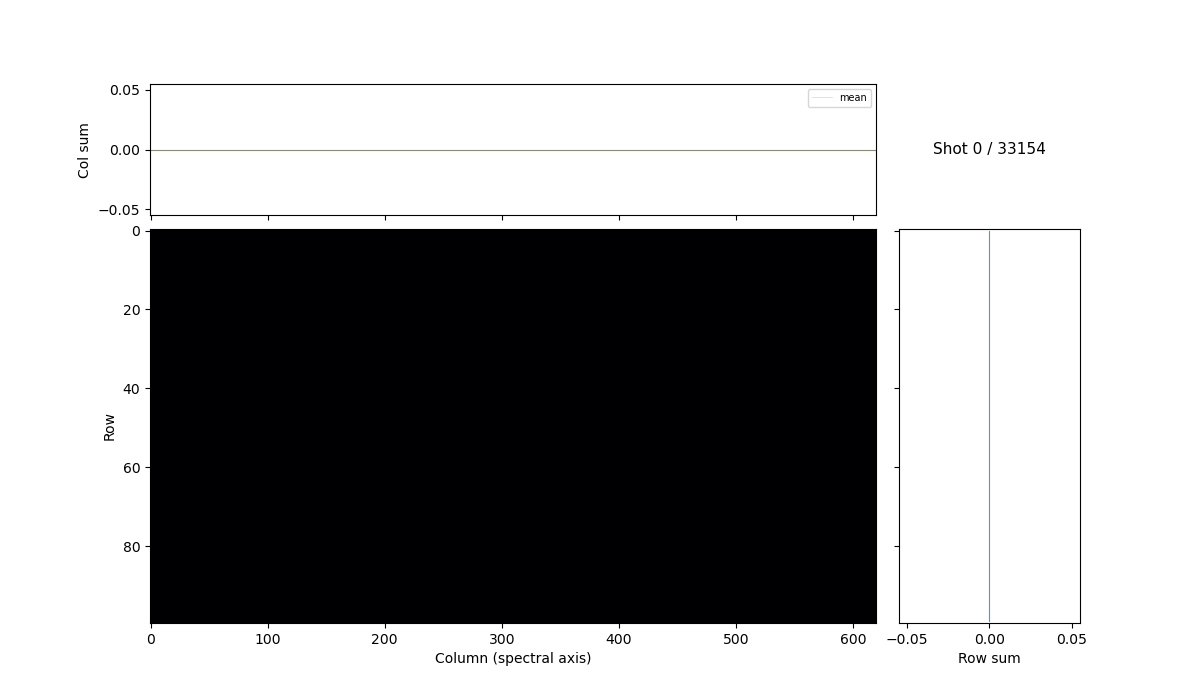

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display

# ── Set up figure with 2D image + marginal projections ──────────────────────
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 2, figure=fig, width_ratios=[4, 1], height_ratios=[1, 3],
              hspace=0.05, wspace=0.05)

ax_img  = fig.add_subplot(gs[1, 0])   # 2D image
ax_col  = fig.add_subplot(gs[0, 0], sharex=ax_img)  # column projection (top)
ax_row  = fig.add_subplot(gs[1, 1], sharey=ax_img)  # row projection (right)
ax_info = fig.add_subplot(gs[0, 1])   # info text
ax_info.axis('off')

# Initial plot
vmax = np.percentile(mean_img, 99)
im = ax_img.imshow(seer_all[0], aspect='auto', origin='upper',
                    cmap='inferno', vmin=0, vmax=vmax, interpolation='nearest')
ax_img.set_xlabel('Column (spectral axis)')
ax_img.set_ylabel('Row')

# Column projection (top)
col_proj = seer_all[0].sum(axis=0)
line_col, = ax_col.plot(np.arange(N_cols), col_proj, lw=0.8, color='steelblue')
line_col_mean, = ax_col.plot(np.arange(N_cols), mean_img.sum(axis=0),
                              lw=0.5, color='orange', alpha=0.5, label='mean')
ax_col.set_ylabel('Col sum')
ax_col.tick_params(labelbottom=False)
ax_col.legend(fontsize=7, loc='upper right')

# Row projection (right)
row_proj = seer_all[0].sum(axis=1)
line_row, = ax_row.plot(row_proj, np.arange(N_rows), lw=0.8, color='steelblue')
line_row_mean, = ax_row.plot(mean_img.sum(axis=1), np.arange(N_rows),
                              lw=0.5, color='orange', alpha=0.5)
ax_row.set_xlabel('Row sum')
ax_row.tick_params(labelleft=False)

title_text = ax_info.text(0.5, 0.5, f'Shot 0 / {N_shots-1}',
                           ha='center', va='center', fontsize=11,
                           transform=ax_info.transAxes)

plt.tight_layout()


# ── Update function ─────────────────────────────────────────────────────────
def update(shot_idx):
    frame = seer_all[shot_idx]
    im.set_data(frame)
    
    col_proj = frame.sum(axis=0)
    row_proj = frame.sum(axis=1)
    
    line_col.set_ydata(col_proj)
    ax_col.set_ylim(0, max(col_proj.max() * 1.1, 1))
    
    line_row.set_xdata(row_proj)
    ax_row.set_xlim(0, max(row_proj.max() * 1.1, 1))
    
    title_text.set_text(f'Shot {shot_idx} / {N_shots-1}\nmax={frame.max():.0f} ADU')
    fig.canvas.draw_idle()


# ── Slider widget ──────────────────────────────────────────────────────────
slider = widgets.IntSlider(
    value=0, min=0, max=N_shots-1, step=1,
    description='Shot:', continuous_update=False,
    layout=widgets.Layout(width='80%')
)
slider.observe(lambda change: update(change['new']), names='value')

# Play button for animation
play = widgets.Play(value=0, min=0, max=N_shots-1, step=1,
                     interval=200, description='Play')
widgets.jslink((play, 'value'), (slider, 'value'))

display(widgets.HBox([play, slider]))

## Static peak identification

To find columns with static (non-varying) sharp peaks, compare the per-shot  
column projection standard deviation to the mean. Columns where the mean is  
high but std is low (relative to Poisson expectation) are static artifacts.

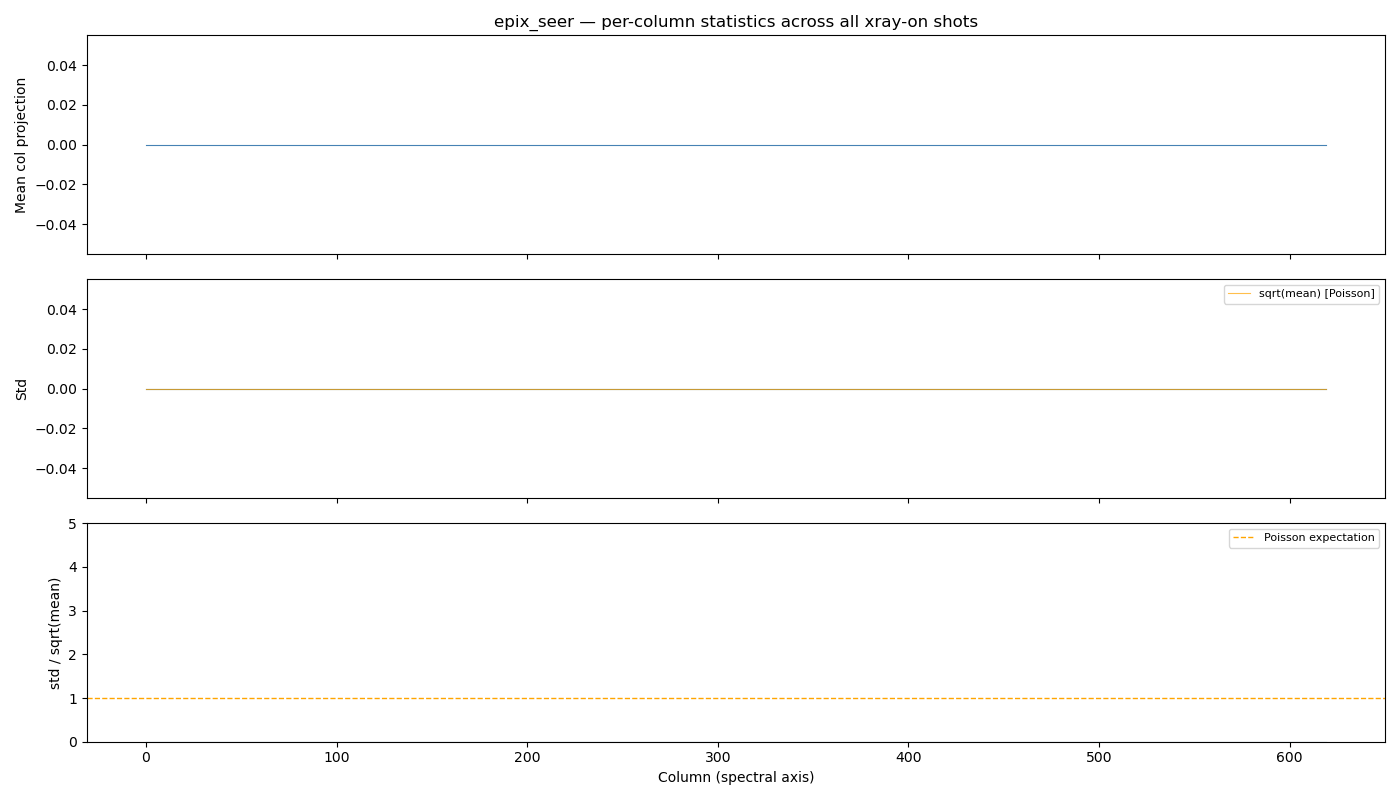


No obvious static artifact columns detected by Poisson criterion.
  Lowest-variability signal columns: []


In [3]:
# Column-wise statistics across all shots
col_projections = seer_all.sum(axis=1)  # (N_shots, N_cols) — sum over rows per shot

col_mean = col_projections.mean(axis=0)  # (N_cols,)
col_std  = col_projections.std(axis=0)   # (N_cols,)

# For Poisson-like signal: expected std ~ sqrt(mean)
# Static peaks have std << sqrt(mean) (they don't vary shot-to-shot)
with np.errstate(divide='ignore', invalid='ignore'):
    poisson_ratio = np.where(col_mean > 0, col_std / np.sqrt(col_mean), 0.0)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(col_mean, lw=0.8, color='steelblue')
axes[0].set_ylabel('Mean col projection')
axes[0].set_title('epix_seer — per-column statistics across all xray-on shots')

axes[1].plot(col_std, lw=0.8, color='steelblue')
axes[1].plot(np.sqrt(col_mean), lw=0.8, color='orange', alpha=0.7, label='sqrt(mean) [Poisson]')
axes[1].set_ylabel('Std')
axes[1].legend(fontsize=8)

axes[2].plot(poisson_ratio, lw=0.8, color='steelblue')
axes[2].axhline(1.0, color='orange', lw=1, ls='--', label='Poisson expectation')
axes[2].set_ylabel('std / sqrt(mean)')
axes[2].set_xlabel('Column (spectral axis)')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 5)

plt.tight_layout()
plt.show()

# Flag static columns: high mean but low relative std
static_mask = (col_mean > np.percentile(col_mean, 90)) & (poisson_ratio < 0.5)
static_cols = list(np.where(static_mask)[0])
if static_cols:
    print(f'\nPotential static artifact columns (high mean, sub-Poisson variability):')
    print(f'  {static_cols}')
else:
    print('\nNo obvious static artifact columns detected by Poisson criterion.')
    # Show columns with lowest poisson_ratio that have significant signal
    sig_mask = col_mean > np.percentile(col_mean, 50)
    low_var = np.argsort(poisson_ratio[sig_mask])[:10]
    low_var_cols = np.where(sig_mask)[0][low_var]
    print(f'  Lowest-variability signal columns: {list(low_var_cols)}')

## ADU Threshold Ringing Diagnostic

The periodic ringing visible in the aggregate column projection likely comes from  
the **ADU threshold interacting with a periodic noise floor**.  

The ePix100 readout has banks (~96 px wide). The pedestal/noise level has a slight  
periodic modulation from the bank electronics. A hard threshold (`< 5 ADU -> 0`)  
clips different fractions of the noise tail at different columns, producing a  
periodic bias in the sum that looks like Fourier ringing.

**Test**: compare the summed spectrum with threshold=5 vs threshold=0 (no threshold).

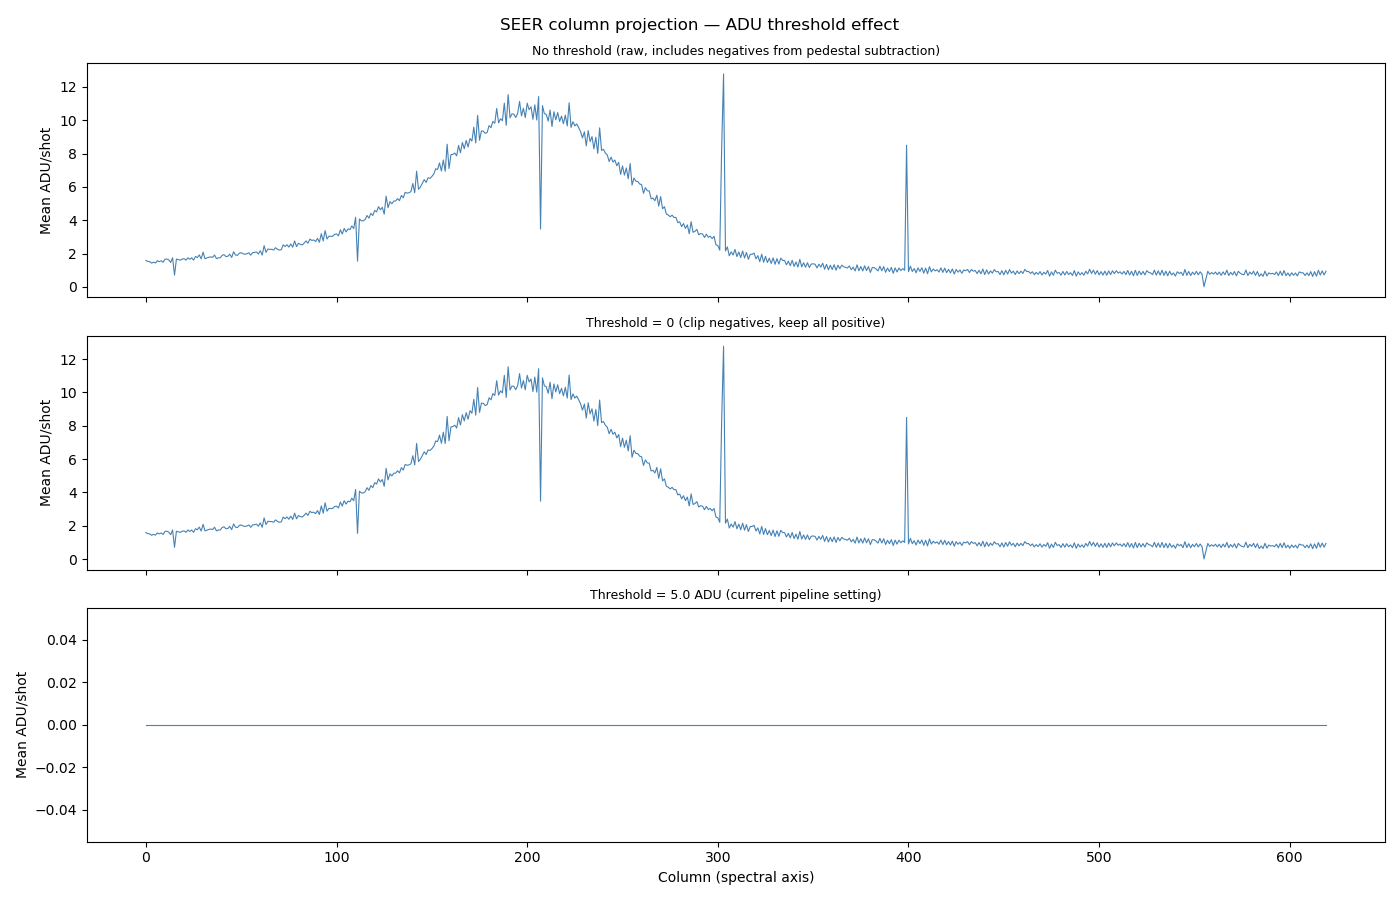

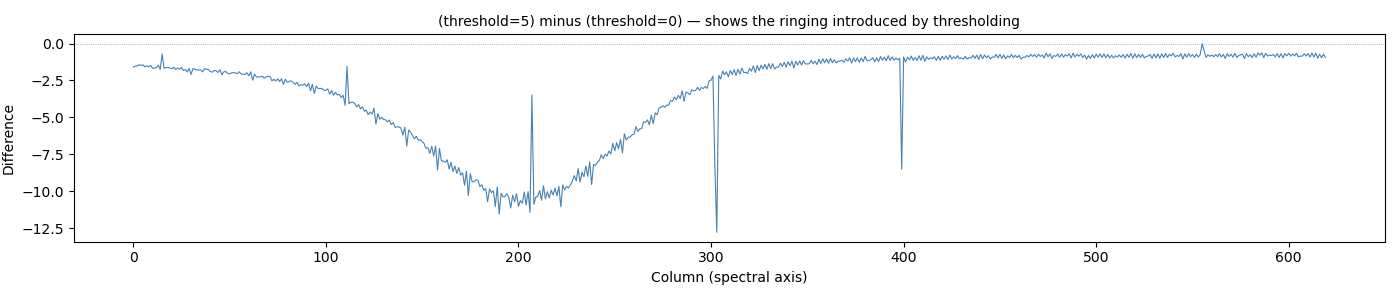

In [4]:
# Reload WITHOUT threshold for comparison
with h5py.File(SMD_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
    seer_no_thresh = f['epix100_1/ROI_area'][:][xray].astype(np.float64)

# Column projections: with threshold vs without
proj_with_thresh = seer_all.sum(axis=1).mean(axis=0)       # ADU >= 5
proj_no_thresh   = seer_no_thresh.sum(axis=1).mean(axis=0) # all pixels
proj_no_thresh_clipped = np.clip(seer_no_thresh, 0, None).sum(axis=1).mean(axis=0)  # >= 0 only

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('SEER column projection — ADU threshold effect', fontsize=12)

axes[0].plot(proj_no_thresh, lw=0.8, color='steelblue')
axes[0].set_ylabel('Mean ADU/shot')
axes[0].set_title('No threshold (raw, includes negatives from pedestal subtraction)', fontsize=9)

axes[1].plot(proj_no_thresh_clipped, lw=0.8, color='steelblue')
axes[1].set_ylabel('Mean ADU/shot')
axes[1].set_title('Threshold = 0 (clip negatives, keep all positive)', fontsize=9)

axes[2].plot(proj_with_thresh, lw=0.8, color='steelblue')
axes[2].set_ylabel('Mean ADU/shot')
axes[2].set_title(f'Threshold = {ADU_THRESH} ADU (current pipeline setting)', fontsize=9)
axes[2].set_xlabel('Column (spectral axis)')

plt.tight_layout()
plt.show()

# Difference: shows what the threshold adds/removes
fig, ax = plt.subplots(1, 1, figsize=(14, 3))
diff = proj_with_thresh - proj_no_thresh_clipped
ax.plot(diff, lw=0.8, color='steelblue')
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Column (spectral axis)')
ax.set_ylabel('Difference')
ax.set_title('(threshold=5) minus (threshold=0) — shows the ringing introduced by thresholding', fontsize=10)
plt.tight_layout()
plt.show()

/lscratch/lbgee/tmp/ipykernel_20794/4150010705.py:8: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs > 0, 1.0 / freqs, 0)  # pixels per cycle


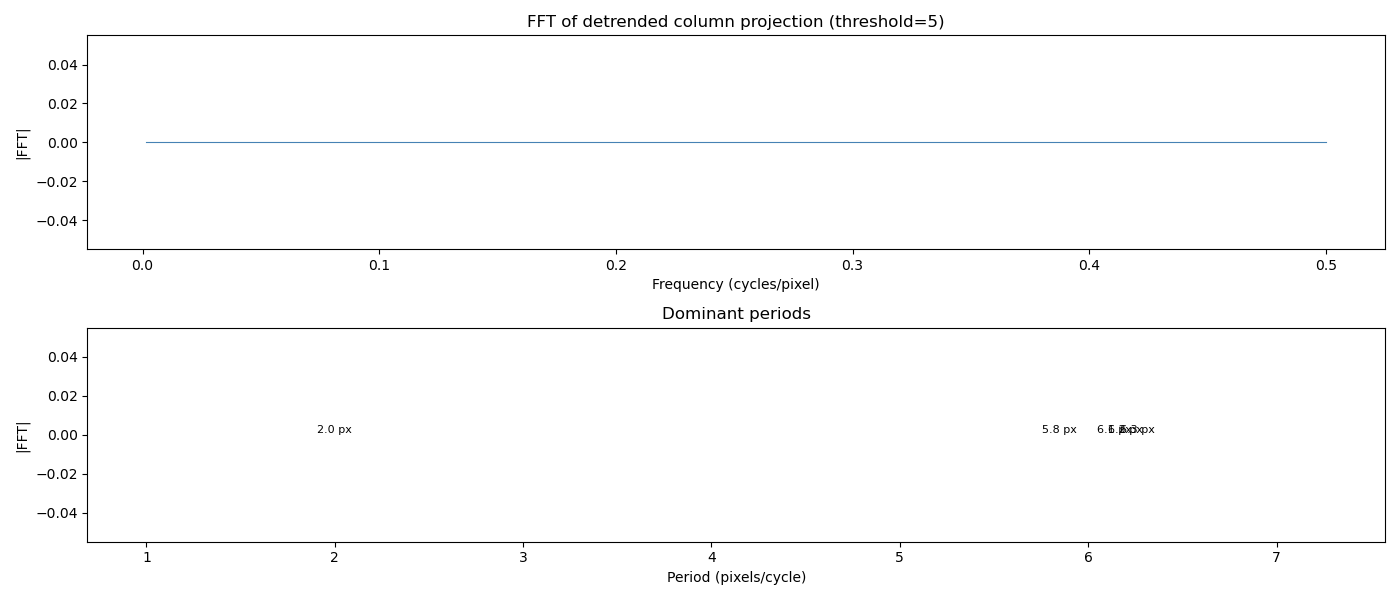

Top 5 dominant periods:
  2.0 pixels/cycle (freq=0.5000 cycles/px)
  5.8 pixels/cycle (freq=0.1710 cycles/px)
  6.3 pixels/cycle (freq=0.1597 cycles/px)
  6.2 pixels/cycle (freq=0.1613 cycles/px)
  6.1 pixels/cycle (freq=0.1629 cycles/px)

ePix100 ASIC bank width = 96 pixels
If the dominant period is ~96 or a harmonic (48, 32, 24),
it confirms the ringing is from readout bank structure.


In [5]:
# FFT of the column projection to identify the ringing period
from scipy.signal import detrend
%matplotlib widget
# Detrend and FFT the thresholded projection
signal = detrend(proj_with_thresh)
fft_mag = np.abs(np.fft.rfft(signal))
freqs = np.fft.rfftfreq(len(signal))  # cycles per pixel
periods = np.where(freqs > 0, 1.0 / freqs, 0)  # pixels per cycle

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(freqs[1:], fft_mag[1:], lw=0.8, color='steelblue')
axes[0].set_xlabel('Frequency (cycles/pixel)')
axes[0].set_ylabel('|FFT|')
axes[0].set_title('FFT of detrended column projection (threshold=5)')

# Show dominant periods
top_idx = np.argsort(fft_mag[1:])[-10:][::-1] + 1
axes[1].bar(periods[top_idx], fft_mag[top_idx], width=2, color='steelblue')
axes[1].set_xlabel('Period (pixels/cycle)')
axes[1].set_ylabel('|FFT|')
axes[1].set_title('Dominant periods')
for idx in top_idx[:5]:
    axes[1].annotate(f'{periods[idx]:.1f} px', (periods[idx], fft_mag[idx]),
                      fontsize=8, ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('Top 5 dominant periods:')
for idx in top_idx[:5]:
    print(f'  {periods[idx]:.1f} pixels/cycle (freq={freqs[idx]:.4f} cycles/px)')
print()
print('ePix100 ASIC bank width = 96 pixels')
print('If the dominant period is ~96 or a harmonic (48, 32, 24),')  
print('it confirms the ringing is from readout bank structure.')

In [6]:
import plotly.express as px

summed = np.nansum(seer_all, axis=0)

fig = px.imshow(mean_img, zmin=-1E-3, zmax=1E-3)
fig.show()

In [7]:
summed

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])